In [1]:
import pandas as pd

In [ ]:
import os
import torch
from tqdm import tqdm

def build_lean_results_dict(root_path):
    root_path = os.path.expanduser(root_path)
    
    if not os.path.exists(root_path):
        print(f"Ścieżka nie istnieje: {root_path}")
        return None

    all_results = {}
    
    subfolders = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]

    for subfolder in tqdm(subfolders, desc="Ładowanie etapów"):
        subfolder_path = os.path.join(root_path, subfolder)
        all_results[subfolder] = {}
        
        model_files = [f for f in os.listdir(subfolder_path) if f.endswith(".pth")]
        
        for file in tqdm(model_files, desc=f" -> {subfolder}", leave=False):
            file_path = os.path.join(subfolder_path, file)
            
            try:
                checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
                
                all_results[subfolder][file] = {
                    'config': checkpoint.get('config'),
                    'history': checkpoint.get('history')
                }
                
                del checkpoint
                
            except Exception as e:
                print(f"⚠️ Błąd w {subfolder}/{file}: {e}")

    return all_results

path_to_drive = "~/Library/CloudStorage/GoogleDrive-mw05062004@gmail.com/Mój dysk/dl_2_trained_models"

results_dict = build_lean_results_dict(path_to_drive)

🔍 Znaleziono 19 folderów eksperymentów.


Ładowanie etapów: 100%|██████████| 19/19 [01:01<00:00,  3.21s/it]


✅ Gotowe! Załadowano dane dla 19 folderów.


In [ ]:
import os
import torch
from tqdm import tqdm

def load_history_from_folder(folder_path):
    folder_path = os.path.expanduser(folder_path)
    
    if not os.path.isdir(folder_path):
        print(f"Folder nie istnieje: {folder_path}")
        return {}

    model_files = [f for f in os.listdir(folder_path) if f.endswith(".pth")]
    results = {}

    print(f"Ładowanie {len(model_files)} modeli z: {os.path.basename(folder_path)}")

    for file in tqdm(model_files, unit="model"):
        file_path = os.path.join(folder_path, file)
        
        try:
            checkpoint = torch.load(file_path, map_location='cpu', weights_only=False)
            
            results[file] = {
                'config': checkpoint.get('config'),
                'history': checkpoint.get('history')
            }
            del checkpoint
            
        except Exception as e:
            print(f"⚠️ Błąd ładowania {file}: {e}")

    return results
specific_folder = "~/Library/CloudStorage/GoogleDrive-mw05062004@gmail.com/Mój dysk/dl_2_trained_models/stage_5_transformer_1_filter"

data = load_history_from_folder(specific_folder)

🔍 Ładowanie 1 modeli z: stage_5_transformer_1_filter


100%|██████████| 1/1 [00:03<00:00,  3.25s/model]


✅ Załadowano 1 modeli.
Przykład (F1): 0.7077


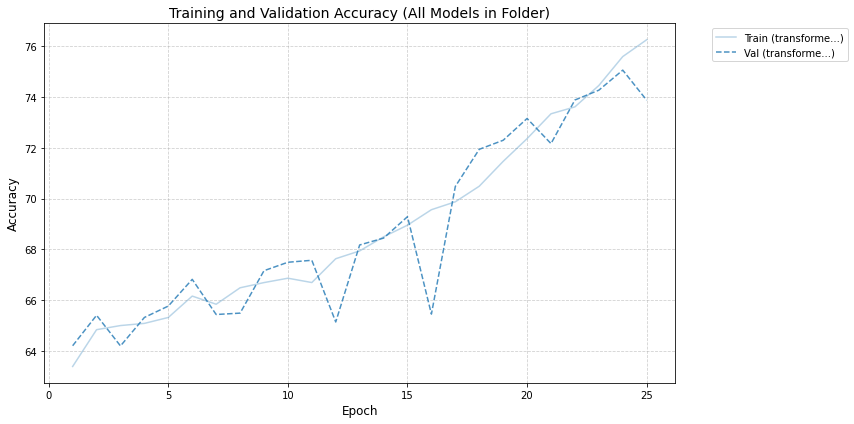

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(data):
    if not data:
        print("Brak danych do wyświetlenia.")
        return

    plt.figure(figsize=(12, 6))
    
    for name, results in data.items():
        history = results.get('history', {})
        train_acc = history.get('train_acc', [])
        val_acc = history.get('val_acc', [])
        epochs = range(1, len(train_acc) + 1)

        line = plt.plot(epochs, train_acc, alpha=0.3, label=f'Train ({name[:10]}...)')
        plt.plot(epochs, val_acc, '--', color=line[0].get_color(), alpha=0.8, label=f'Val ({name[:10]}...)')

    plt.title('Training and Validation Accuracy (All Models in Folder)', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if len(data) < 10:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
plot_training_curves(data)

In [ ]:
def print_dict_stats(results):
    total_models = 0
    print(f"{'Eksperyment':<40} | {'Modele':<7} | {'Status danych'}")
    print("-" * 65)
    
    for stage, models in results.items():
        num_models = len(models)
        total_models += num_models
        
        sample_model = next(iter(models.values())) if models else {}
        has_config = 'config' in sample_model
        has_history = 'history' in sample_model and len(sample_model['history'].get('val_acc', [])) > 0
        
        status = "✅ OK" if has_config and has_history else "⚠️ Niepełne"
        print(f"{stage:<40} | {num_models:<7} | {status}")
    
    print("-" * 65)
    print(f"ŁĄCZNIE: {total_models} modeli w pamięci.")

print_dict_stats(results_dict)

Eksperyment                              | Modele  | Status danych
-----------------------------------------------------------------
stage_2_cnn_deep_search                  | 30      | ✅ OK
stage_4_cnn_2                            | 1       | ✅ OK
stage_2_pretrained_strategy_search       | 3       | ✅ OK
stage_2_transformer_deep_search          | 45      | ✅ OK
stage_4_cnn_3                            | 1       | ✅ OK
stage_5_cnn_1_filter                     | 1       | ✅ OK
stage_1_baseline_cnn                     | 1       | ✅ OK
stage_4_transformer_1                    | 1       | ✅ OK
stage_5_transformer_1_filter             | 1       | ✅ OK
stage_5_cnn_1_sampling                   | 1       | ✅ OK
stage_4_cnn_1                            | 1       | ✅ OK
stage_5_transformer_1_command            | 1       | ✅ OK
stage_4_transformer_2                    | 1       | ✅ OK
stage_1_baseline_transformer_scratch     | 1       | ✅ OK
stage_5_transformer_1_sampling           | 1       | ✅ 

In [36]:
results_all_from_stage_4 = {k: v for k, v in results_dict.items() if "stage_4" in k}

In [54]:
sampling_results_from_stage_5 = {k: v for k, v in results_dict.items() if "stage_5" in k and "sampling" in k}

In [37]:
print_dict_stats(results_all_from_stage_4)

Eksperyment                              | Modele  | Status danych
-----------------------------------------------------------------
stage_4_cnn_2                            | 1       | ✅ OK
stage_4_cnn_3                            | 1       | ✅ OK
stage_4_transformer_1                    | 1       | ✅ OK
stage_4_cnn_1                            | 1       | ✅ OK
stage_4_transformer_2                    | 1       | ✅ OK
stage_4_transformer_3                    | 1       | ✅ OK
stage_4_pretrained                       | 2       | ✅ OK
-----------------------------------------------------------------
ŁĄCZNIE: 8 modeli w pamięci.


In [ ]:
import json
import numpy as np

def save_results_to_json(results, filename="stage_2_results.json"):
    def convert_to_serializable(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, dict):
            return {k: convert_to_serializable(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [convert_to_serializable(i) for i in obj]
        return obj

    serializable_results = convert_to_serializable(results)
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable_results, f, indent=4, ensure_ascii=False)
    
    print(f"Plik zapisany jako: {os.path.abspath(filename)}")

save_results_to_json(results_all_from_stage_4, filename="stage_4_results.json")

🔄 Konwertuję dane i zapisuję do JSON (to może chwilę potrwać)...
✅ Plik zapisany jako: /Users/michalwietecki/Desktop/pw/8_sem/deep-learning/speech-classification-deep-learning/stage_4_results.json


In [55]:
save_results_to_json(sampling_results_from_stage_5, filename="stage_5_results_sampling.json")

🔄 Konwertuję dane i zapisuję do JSON (to może chwilę potrwać)...
✅ Plik zapisany jako: /Users/michalwietecki/Desktop/pw/8_sem/deep-learning/speech-classification-deep-learning/stage_5_results_sampling.json


In [ ]:
import pandas as pd
import numpy as np

def summarize_stage_4(results):
    summary_data = []
    s4_keys = [k for k in results.keys() if 'stage_4' in k or 'pretrained' in k]
    
    for stage in s4_keys:
        for model_name, data in results[stage].items():
            h = data['history']
            c = data['config']
            summary_data.append({
                'Stage': stage,
                'Model Name': model_name,
                'Final Acc (%)': h['val_acc'][-1],
                'Max Acc (%)': max(h['val_acc']),
                'Final F1': h['val_f1'][-1],
                'Max F1': max(h['val_f1']),
                'Epochs': len(h['val_acc'])
            })
    
    df_final = pd.DataFrame(summary_data).sort_values(by='Final F1', ascending=False)
    return df_final

final_ranking = summarize_stage_4(results_all_from_stage_4)
print(final_ranking.to_string(index=False))

--- RANKING FINALISTÓW (STAGE 4) ---
                Stage                            Model Name  Final Acc (%)  Max Acc (%)  Final F1   Max F1  Epochs
        stage_4_cnn_1                               cnn.pth      96.126629    96.178771  0.960864 0.961423      25
        stage_4_cnn_2                               cnn.pth      93.653631    93.683426  0.935690 0.936461      25
        stage_4_cnn_3                               cnn.pth      93.497207    94.696462  0.933213 0.946053      25
stage_4_transformer_1                       transformer.pth      92.625698    92.625698  0.925236 0.925236      25
   stage_4_pretrained    pretrained_trans_strategy_none.pth      92.551210    92.618250  0.924197 0.925030      25
stage_4_transformer_2                       transformer.pth      92.119181    92.119181  0.919971 0.919971      25
stage_4_transformer_3                       transformer.pth      91.649907    91.955307  0.916319 0.918843      25
   stage_4_pretrained pretrained_trans_stra

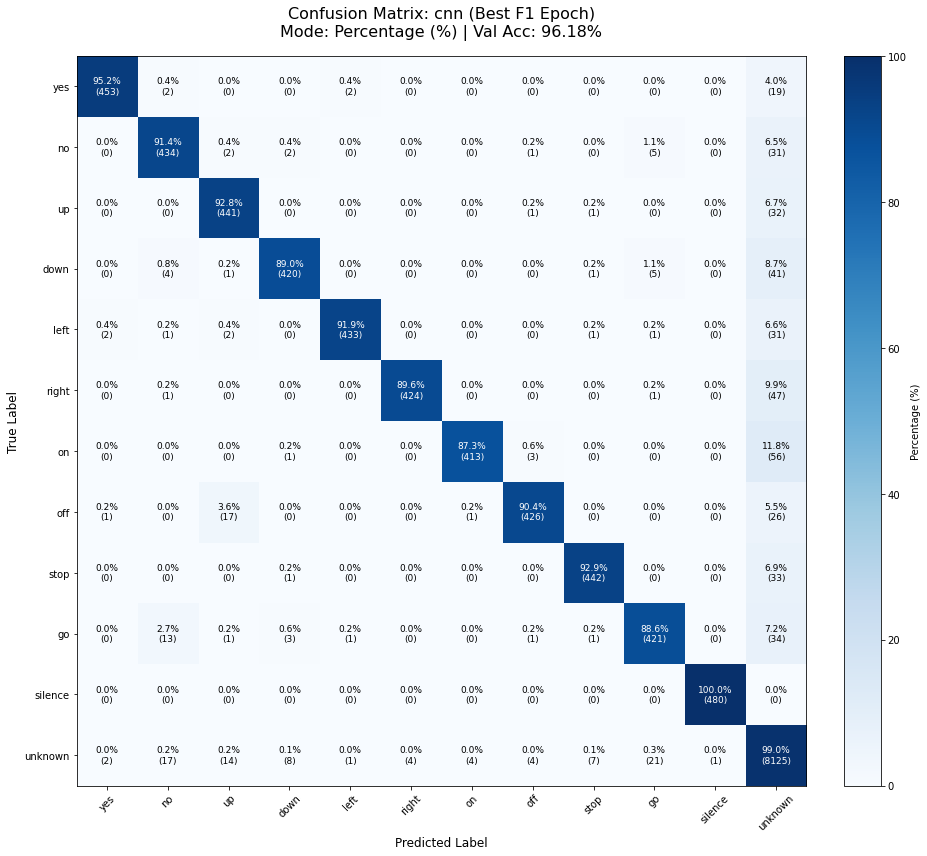

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_best_confusion_matrix(results, stage, model_name_no_ext, normalize=False):
    class_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "silence", "unknown"]
    file_name = f"{model_name_no_ext}.pth"
    
    if stage not in results or file_name not in results[stage]:
        print(f"Nie znaleziono modelu {file_name} w etapie {stage}")
        return


    history = results[stage][file_name]['history']
    best_idx = np.argmax(history['val_f1'])
    cm_abs = np.array(history['val_cm'][best_idx])
    

    cm_perc = cm_abs.astype('float') / cm_abs.sum(axis=1)[:, np.newaxis]
    cm_perc = np.nan_to_num(cm_perc) * 100 

    num_classes = cm_abs.shape[0]
    plt.figure(figsize=(14, 12))
    

    data_to_plot = cm_perc if normalize else cm_abs
    label_type = "Percentage (%)" if normalize else "Absolute Count"
    
    im = plt.imshow(data_to_plot, cmap='Blues', aspect='equal')
    plt.colorbar(im, fraction=0.046, pad=0.04).set_label(label_type)

    plt.title(f"Confusion Matrix: {model_name_no_ext} (Best F1 Epoch)\n"
              f"Mode: {label_type} | Val Acc: {history['val_acc'][best_idx]:.2f}%", 
              fontsize=16, pad=20)
    
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)

    ticks = np.arange(num_classes)
    plt.xticks(ticks, class_names, fontsize=10, rotation=45)
    plt.yticks(ticks, class_names, fontsize=10)

    threshold = data_to_plot.max() / 2.
    for i in range(num_classes):
        for j in range(num_classes):
            abs_val = int(cm_abs[i, j])
            perc_val = cm_perc[i, j]
            
            if normalize:
                text = f"{perc_val:.1f}%\n({abs_val})"
            else:
                text = f"{abs_val}"
            
            plt.text(j, i, text,
                     ha="center", va="center",
                     color="white" if data_to_plot[i, j] > threshold else "black",
                     fontsize=9)

    plt.tight_layout()
    plt.show()
plot_best_confusion_matrix(results_all_from_stage_4, 'stage_4_cnn_1', 'cnn', normalize=True)

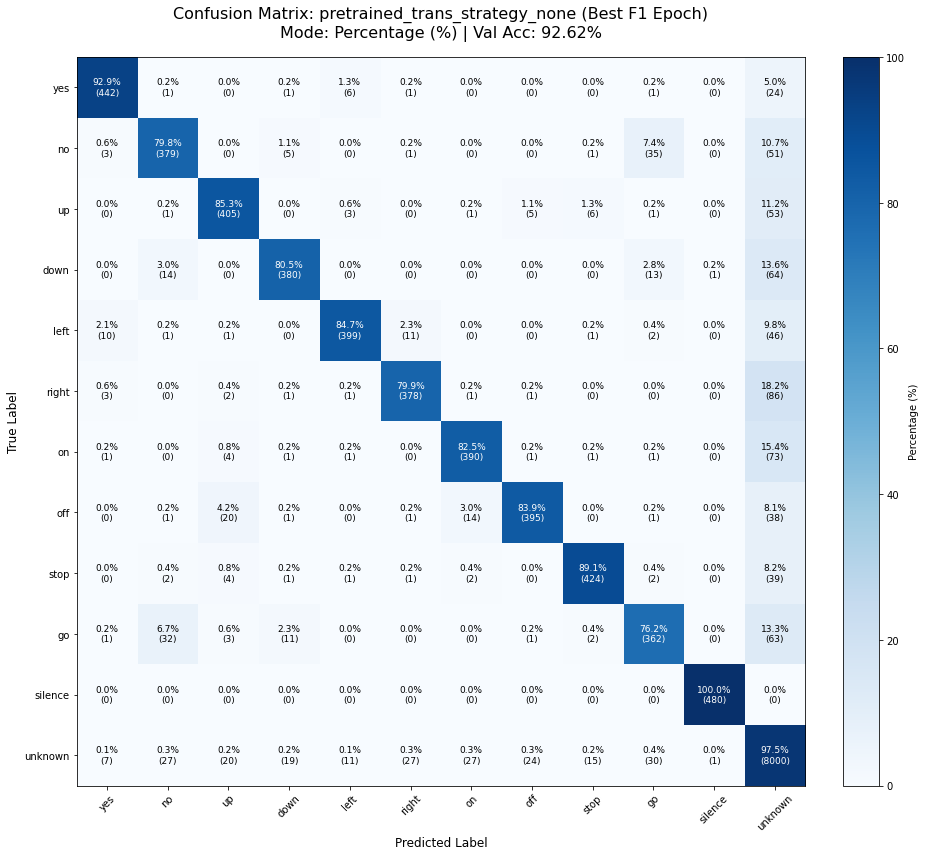

In [25]:
plot_best_confusion_matrix(results_all_from_stage_4, 'stage_4_pretrained', 'pretrained_trans_strategy_none', normalize=True)

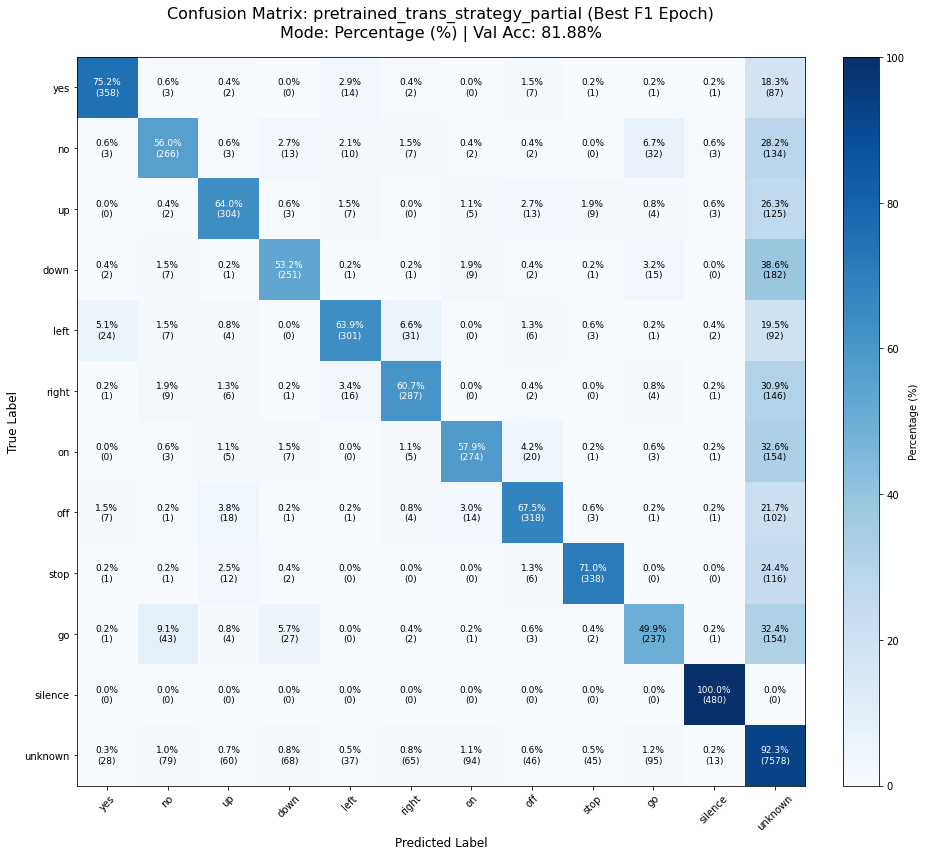

In [26]:
plot_best_confusion_matrix(results_all_from_stage_4, 'stage_4_pretrained', 'pretrained_trans_strategy_partial', normalize=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_class_difficulty_comparison(results, class_names):
    try:
        idx_unknown = class_names.index("unknown")
        idx_silence = class_names.index("silence")
    except ValueError:
        print("Upewnij się, że 'unknown' i 'silence' są na liście class_names.")
        return

    models_data = []
    
    s4_keys = [k for k in results.keys() if 'stage_4' in k or 'pretrained' in k]
    for stage in s4_keys:
        for model_name, data in results[stage].items():
            hist = data['history']
            

            best_idx = np.argmax(hist['val_f1'])
            cm = np.array(hist['val_cm'][best_idx])
            

            row_sums = cm.sum(axis=1)
            recall_per_class = np.divide(np.diag(cm), row_sums, out=np.zeros_like(row_sums, dtype=float), where=row_sums!=0)
            recall_per_class *= 100
            
            rec_unknown = recall_per_class[idx_unknown]
            rec_silence = recall_per_class[idx_silence]
            

            other_indices = [i for i in range(len(class_names)) if i not in (idx_unknown, idx_silence)]
            rec_others_mean = np.mean(recall_per_class[other_indices])

            short_name = model_name.replace('.pth', '').replace('stage_4_', '')
            if len(short_name) > 15:
                short_name = short_name[:15] + "..."
                
            models_data.append({
                'name': short_name,
                'unknown': rec_unknown,
                'silence': rec_silence,
                'others': rec_others_mean
            })


    labels = [d['name'] for d in models_data]
    val_unknown = [d['unknown'] for d in models_data]
    val_silence = [d['silence'] for d in models_data]
    val_others = [d['others'] for d in models_data]

    x = np.arange(len(labels))
    width = 0.25  

    fig, ax = plt.subplots(figsize=(14, 7))
    
    rects1 = ax.bar(x - width, val_unknown, width, label='Unknown', color='#ff9999', edgecolor='black')
    rects2 = ax.bar(x, val_silence, width, label='Silence', color='#66b3ff', edgecolor='black')
    rects3 = ax.bar(x + width, val_others, width, label='Mean of Commands', color='#99ff99', edgecolor='black')


    ax.set_ylabel('Recall / Accuracy per Class (%)', fontsize=12)
    ax.set_title('Difficulty by Class Category Across All Final Models', fontsize=16, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.legend(title='Category', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 105)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.show()

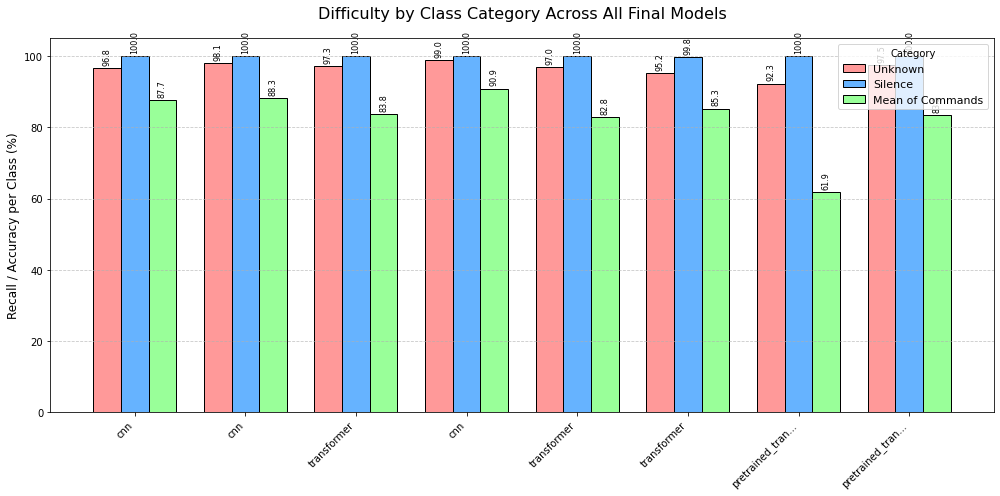

In [23]:
class_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "silence", "unknown"]
plot_class_difficulty_comparison(results_all_from_stage_4, class_names)

✅ Dodano macierz z: stage_4_cnn_1 -> cnn.pth (F1: 0.9614)
✅ Dodano macierz z: stage_4_transformer_1 -> transformer.pth (F1: 0.9252)


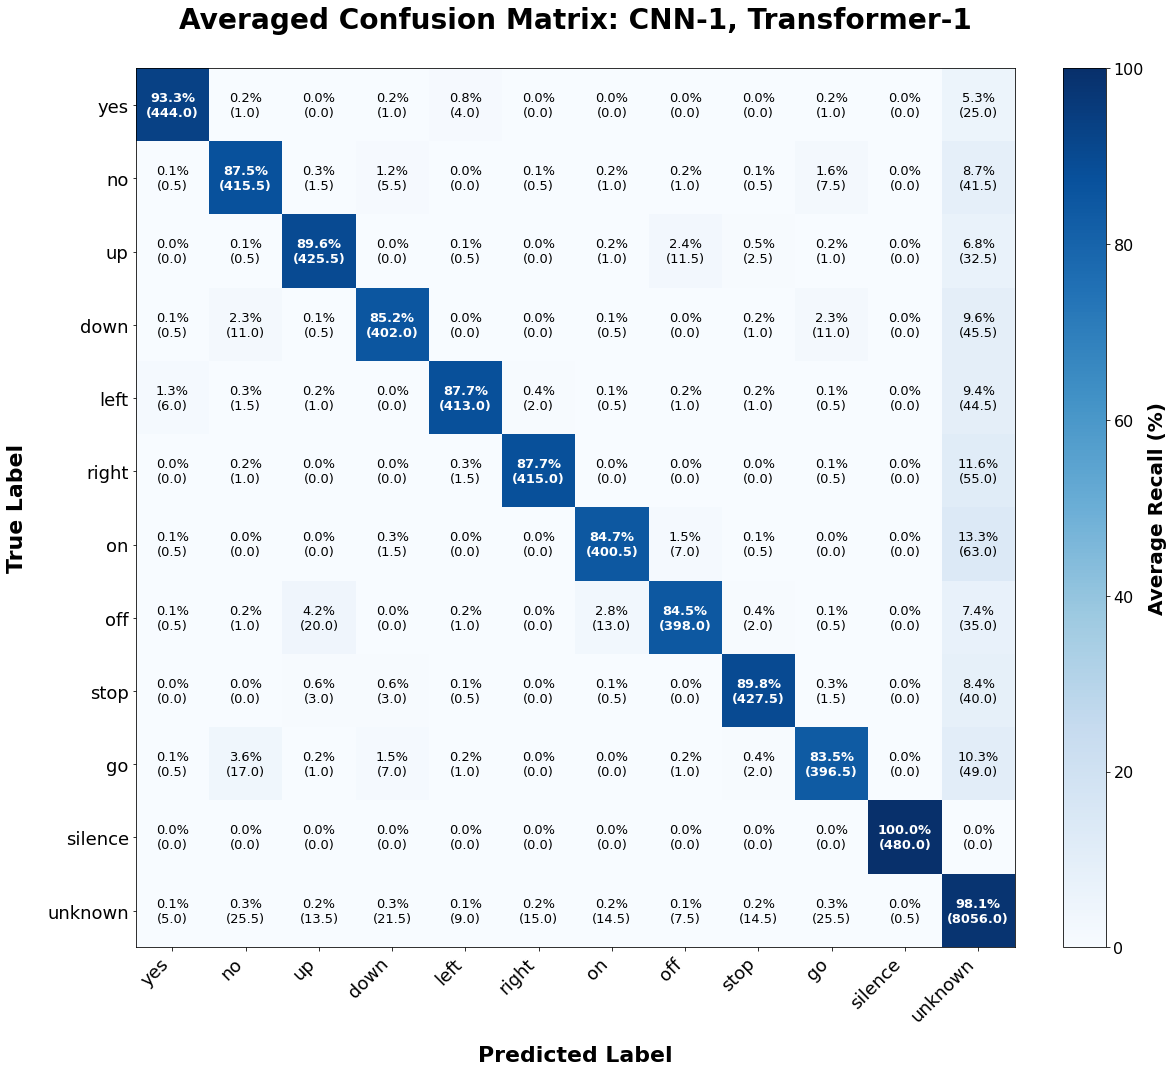

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_averaged_confusion_matrix_v2(results_dict, selected_stages, title_suffix="Final Models"):
    class_names = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "silence", "unknown"]
    all_cms = []


    for stage in selected_stages:
        if stage in results_dict:

            for model_file, data in results_dict[stage].items():
                history = data['history']
                

                best_idx = np.argmax(history['val_f1'])
                
                cm = np.array(history['val_cm'][best_idx])
                all_cms.append(cm)
                print(f"Dodano macierz z: {stage} -> {model_file} (F1: {history['val_f1'][best_idx]:.4f})")
        else:
            print(f"Nie znaleziono folderu: {stage}")



    cm_avg_abs = np.mean(all_cms, axis=0)
    

    row_sums = cm_avg_abs.sum(axis=1)[:, np.newaxis]
    cm_avg_perc = np.divide(cm_avg_abs, row_sums, out=np.zeros_like(cm_avg_abs), where=row_sums!=0) * 100


    num_classes = len(class_names)
    fig, ax = plt.subplots(figsize=(18, 15))
    
    im = ax.imshow(cm_avg_perc, cmap='Blues', aspect='equal')
    

    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Average Recall (%)", fontsize=20, fontweight='bold')
    cbar.ax.tick_params(labelsize=16)

    ax.set_title(f"Averaged Confusion Matrix: {title_suffix}", fontsize=28, pad=40, fontweight='bold')
    
    ax.set_xlabel("Predicted Label", fontsize=22, fontweight='bold', labelpad=20)
    ax.set_ylabel("True Label", fontsize=22, fontweight='bold', labelpad=20)

    ticks = np.arange(num_classes)
    ax.set_xticks(ticks)
    ax.set_xticklabels(class_names, fontsize=18, rotation=45, ha='right')
    ax.set_yticks(ticks)
    ax.set_yticklabels(class_names, fontsize=18)

    threshold = cm_avg_perc.max() / 2.
    for i in range(num_classes):
        for j in range(num_classes):
            abs_val = cm_avg_abs[i, j]
            perc_val = cm_avg_perc[i, j]
            

            text = f"{perc_val:.1f}%\n({abs_val:.1f})"
            
            ax.text(j, i, text,
                     ha="center", va="center",
                     color="white" if cm_avg_perc[i, j] > threshold else "black",
                     fontsize=13, 
                     fontweight='bold' if i == j else 'normal')

    plt.tight_layout()
    plt.show()

folders_to_average = ['stage_4_cnn_1', 'stage_4_transformer_1']

plot_averaged_confusion_matrix_v2(results_dict, folders_to_average, title_suffix="CNN-1, Transformer-1")